In [ ]:
# Name: DVN Surya Kiran
# Roll No: CH.SC.U4CSE24116
# Lab 9 Exercise 1 - KNN Handwritten Digit Recognition

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import seaborn as sn
import pandas as pd

In [ ]:
digits = load_digits()
x = digits.data
y = digits.target
print("Dataset shape:", x.shape)
print("Number of classes:", len(np.unique(y)))
print("Classes:", np.unique(y))

Dataset shape: (1797, 64)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


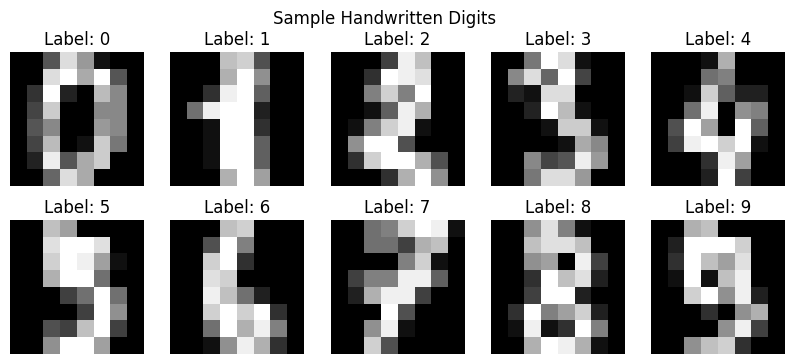

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f'Label: {digits.target[i]}')
    ax.axis('off')
plt.suptitle('Sample Handwritten Digits')
plt.show()

In [ ]:
print("Null values:", np.isnan(x).sum())
print("Dataset shape:", x.shape)

Null values: 0
Dataset shape: (1797, 64)


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(x_train.shape, x_test.shape)

(1437, 64) (360, 64)


In [ ]:
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [ ]:
results = []
for i in [1, 2, 3, 4, 5]:
    model = KNeighborsClassifier(n_neighbors=i, metric='minkowski', p=2)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    acc = metrics.accuracy_score(y_test, y_pred)
    results.append(acc)
    print(f"K={i} Accuracy: {int(acc*100)}%")

K=1 Accuracy: 97%
K=2 Accuracy: 96%
K=3 Accuracy: 96%
K=4 Accuracy: 96%
K=5 Accuracy: 97%


In [ ]:
model = KNeighborsClassifier(n_neighbors=3, metric='minkowski', p=2)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [ ]:
conf_mat = metrics.confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_mat)
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("Accuracy %:", int(metrics.accuracy_score(y_test, y_pred)*100), '%')
print("\nClassification Report:\n", metrics.classification_report(y_test, y_pred))

Confusion Matrix:
 [[33  0  0  0  0  0  0  0  0  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  1 32  0  0  0  0  0  0  0]
 [ 0  0  1 33  0  0  0  0  0  0]
 [ 0  0  0  0 46  0  0  0  0  0]
 [ 0  0  0  0  0 45  1  0  0  1]
 [ 0  0  0  0  0  0 35  0  0  0]
 [ 0  0  0  0  0  0  0 33  0  1]
 [ 0  1  1  0  0  0  0  0 28  0]
 [ 0  0  0  1  1  1  0  0  1 36]]
Accuracy: 0.9694444444444444
Accuracy %: 96 %

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.93      1.00      0.97        28
           2       0.94      0.97      0.96        33
           3       0.97      0.97      0.97        34
           4       0.98      1.00      0.99        46
           5       0.98      0.96      0.97        47
           6       0.97      1.00      0.99        35
           7       1.00      0.97      0.99        34
           8       0.97      0.93      0.95        30
           9       0.95      0.90     

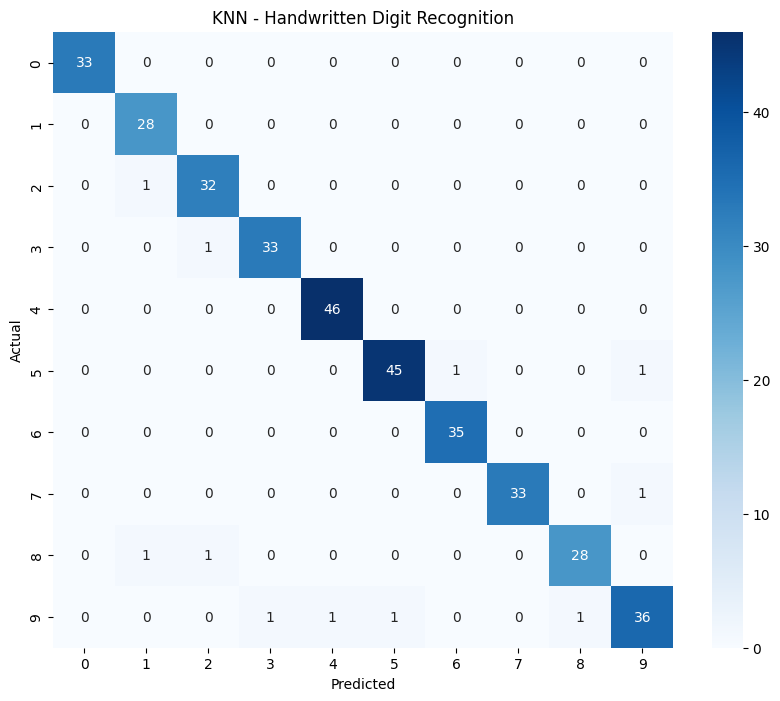

In [ ]:
plt.figure(figsize=(10, 8))
sn.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.title('KNN - Handwritten Digit Recognition')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

   K  Accuracy
0  1  0.977778
1  2  0.961111
2  3  0.969444
3  4  0.961111
4  5  0.975000


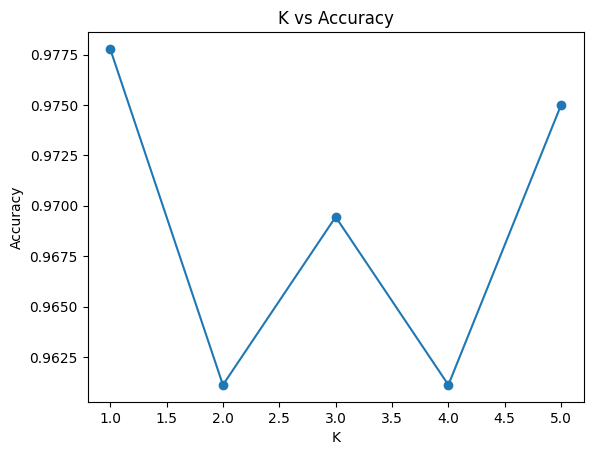

In [ ]:
models_df = pd.DataFrame({
    'K': [1, 2, 3, 4, 5],
    'Accuracy': results
})
print(models_df)
plt.plot([1,2,3,4,5], results, marker='o')
plt.title('K vs Accuracy')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.show()

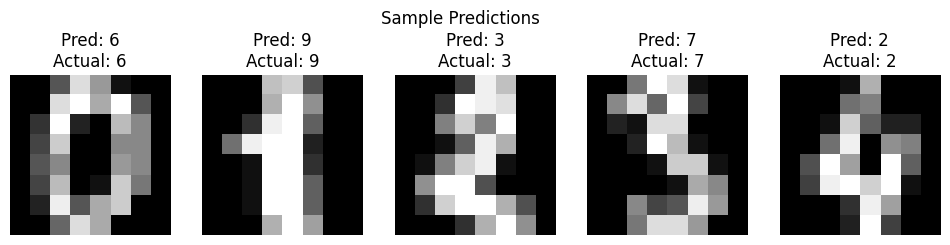

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f'Pred: {y_pred[i]}\nActual: {y_test[i]}')
    ax.axis('off')
plt.suptitle('Sample Predictions')
plt.show()